# Within-site null models for the entrenchment criterion

Reviewer 3, major point 1, argues that our criterion — median log f(A→B) < −1 **and**
median log f(B→A) < −1 — "will produce hits whenever a site is under strong purifying
selection in general," and that multiple entrenched pairs per site is "the signature
expected if substitutions at those sites are simply disfavoured in all directions rather
than entrenched with respect to a specific alternative amino acid."

This notebook asks the empirical question inside that objection: **at a given site and
germline parent amino acid, are the entrenched substitutions more disfavoured than the
other substitutions available from that same parent?**

## A null result here would not weaken the claim

Reciprocal disfavour cannot be produced by site-level constraint of any strength:

> Suppose two V genes differ only at site 50, one carrying G and one carrying W. If G→W is
> disfavoured in the G background, then W→G must be *favoured* in the W background, because
> the two substitutions interconvert the same pair of proteins. Only when the genes also
> differ at some other site X can both directions be disfavoured — and that is precisely a
> statement that site 50 interacts epistatically with X. Whether W is also disfavoured
> toward other amino acids does not bear on this argument.

So a site that is broadly intolerant *and* holds different germline residues in different
backgrounds, each disfavoured toward the other, is still entrenched. What follows is the
separate question of whether entrenched substitutions are additionally distinguished within
their site.

## What is implemented

**Versions A and B** are the reviewer's Null 1 readout (1) — the rank of a measured
selection factor within its parent's pool — aggregated to where it has power. A works per
(site, parent AA) group with exact enumeration; B pools all groups. Their per-pair version
floors out at 0.11–0.20 given realistic pool sizes, so it cannot reach significance alone;
it is printed alongside Version A as the literal form of the same numbers.

**Readout (2)** is a different question, not a coarser version of the first. Its units are
all tested pairs rather than the calls, and it asks whether the real germline partner
crosses −1 more often than a randomly substituted neighbour would — whether B is disfavoured
toward A *specifically* rather than toward its alternatives generally. Entrenchment does not
require that: it requires A→B and B→A both to be disfavoured, not that B is the worst thing
A could become.

Its name is misleading too. To be a candidate entrenchment call both residues must be
germline at that site, since that is what makes both directions measurable; the random X
drawn in their null is usually a residue no V gene carries there, so the configurations it
counts could never have been tested. The ratio is not a false discovery rate.

Grantham-matched pooling (R3's Null 2, and their major point 3) is not implemented here; it
is a filter on the same pools and belongs with the response to that point.

In [1]:
import os
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from utils import load_and_process_dasm_data, load_entrenched_sites

# --- Configuration (matches the entrenchment analysis in v_families_entrenchment_dasm.ipynb) ---
MODEL_NAME = "dasm_4m-v1jaffeCC+v1tangCC-joint"
DATASET_NAME = "v1rodriguez"
NUMBERING_SCHEME = "chothia"
ENTRENCHMENT_DIR = f"_output/entrenchment_analysis"
FIGURES_DIR = "figures"
THRESHOLD = -1.0          # entrenchment cutoff on median log selection factor
MIN_OBS_PER_COMBO = 10    # >=10 distinct PCPs per (v_family, site, parent_aa)
PCP_DEPTH = 2             # MRCA parent-child pairs only
N_PERM = 10_000
SEED = 0

MEDIAN_TABLE_PATH = f"{ENTRENCHMENT_DIR}/{NUMBERING_SCHEME}/median_lsf_all_targets.csv"

COMPARISONS = [
    ("within_IGHV1", "IGHV1", "IGHV1"),
    ("within_IGHV3", "IGHV3", "IGHV3"),
    ("IGHV1_vs_IGHV3", "IGHV1", "IGHV3"),
]

## Step 1 — the per-direction median table

The quantity every test below needs is the median log selection factor for **every**
(V family, site, parent AA, target AA) one nucleotide away — including targets that are not
a germline option at that site, which is what makes the reviewer's comparison pools
possible. The published `comparison_*.csv` files keep only germline↔germline pairs, so this
has to be built from DASM inference.

Building it takes a few minutes, so it is cached to `median_lsf_all_targets.csv` and
reloaded on later runs. Delete that file to force a rebuild.

Either way we re-derive every entrenchment call from it and require an exact match against
the published calls. A mismatch means the filtering has drifted and every result below is
meaningless, so it fails loudly.

In [2]:
def build_median_table(df, min_obs=MIN_OBS_PER_COMBO, depth=PCP_DEPTH):
    """Median log selection factor per (v_family, site, parent_aa, target_aa).

    Matches the filtering used for the entrenchment calls, but keeps ALL 1nt-reachable
    targets rather than merging down to germline<->germline pairs.
    """
    kept = df[(df.depth == depth) & (df.one_mutation_away == True) & (df.is_germline_codon == True)]
    kept = kept.dropna(subset=["log_selection_factor"])

    counts = (
        kept[["v_family", "site", "parent_aa", "pcp_index"]]
        .drop_duplicates()
        .groupby(["v_family", "site", "parent_aa"])
        .size()
        .reset_index(name="n_pcps")
    )
    keep = counts[counts.n_pcps >= min_obs]
    kept = kept.merge(keep[["v_family", "site", "parent_aa"]],
                      on=["v_family", "site", "parent_aa"], how="inner")

    med = (
        kept.groupby(["v_family", "site", "parent_aa", "selection_factor_target_aa"])
        .log_selection_factor.median()
        .reset_index()
        .rename(columns={"selection_factor_target_aa": "target_aa",
                         "log_selection_factor": "median_lsf"})
    )
    return med.merge(keep, on=["v_family", "site", "parent_aa"], how="left")


if os.path.exists(MEDIAN_TABLE_PATH):
    median_table = pd.read_csv(MEDIAN_TABLE_PATH)
    print(f"loaded cached {MEDIAN_TABLE_PATH}")
else:
    print("no cache found — running DASM inference (several minutes)")
    *_, aa_site_subs_selection_df_germline = load_and_process_dasm_data(
        model_name=MODEL_NAME, dataset_name=DATASET_NAME,
        numbering_scheme=NUMBERING_SCHEME, figures_dir=FIGURES_DIR,
    )
    median_table = build_median_table(aa_site_subs_selection_df_germline)
    os.makedirs(os.path.dirname(MEDIAN_TABLE_PATH), exist_ok=True)
    median_table.to_csv(MEDIAN_TABLE_PATH, index=False)
    print(f"built and saved {MEDIAN_TABLE_PATH}")

median_table["site"] = median_table.site.astype(str)   # Chothia insertion codes are strings
print(f"{len(median_table):,} (v_family, site, parent, target) medians")

# --- the published calls must be reproducible from this table ---
_, _, pairwise, _, _, _ = load_entrenched_sites(NUMBERING_SCHEME, base_dir=ENTRENCHMENT_DIR)
lsf_lookup = {(r.v_family, r.site, r.parent_aa, r.target_aa): r.median_lsf
              for r in median_table.itertuples(index=False)}

for name, _, _ in COMPARISONS:
    cmp_df = pairwise[name]
    mismatches = []
    for r in cmp_df.itertuples(index=False):
        aa_a, aa_b = r.parent_aa_1_and_target_aa_2, r.parent_aa_2_and_target_aa_1
        f_ab = lsf_lookup.get((r.v_family_1, r.site, aa_a, aa_b))
        f_ba = lsf_lookup.get((r.v_family_2, r.site, aa_b, aa_a))
        if f_ab is None or f_ba is None:
            mismatches.append((r.site, aa_a, aa_b, "missing median"))
        elif ((f_ab < THRESHOLD) and (f_ba < THRESHOLD)) != bool(r.is_entrenched):
            mismatches.append((r.site, aa_a, aa_b, "call disagrees"))
    if mismatches:
        raise ValueError(f"{name}: median_table does not reproduce the published calls: {mismatches}")
    print(f"  {name}: {len(cmp_df)} pairs, {int(cmp_df.is_entrenched.sum())} entrenched — reproduced exactly")

loaded cached _output/entrenchment_analysis/chothia/median_lsf_all_targets.csv
5,777 (v_family, site, parent, target) medians
  within_IGHV1: 190 pairs, 16 entrenched — reproduced exactly
  within_IGHV3: 260 pairs, 22 entrenched — reproduced exactly
  IGHV1_vs_IGHV3: 202 pairs, 17 entrenched — reproduced exactly


## Step 2 — groups, and how far each site is from "disfavoured in all directions"

A **group** is one (V family, site, germline parent AA); its members are the amino acids one
nucleotide away from that parent's germline codon. A target is labelled entrenched when the
pair it forms with the parent is a published call. Each call contributes two directed cells,
one in each parent's group, so both directions are tested. Groups with no entrenched target
are dropped — they contribute nothing to either the statistic or the null.

Two statistics are attached to each target, both computed **within** the group so that a
site where everything sits at −2 contributes no signal merely from being constrained:

- **normalised rank**, `(rank − 0.5) / n`, ascending in selection factor. Scale-free, one
  vote per target, robust to a single extreme value. A target drawn at random sits at 0.5.
- **within-group z-score**, `(x − mean) / sd`. Keeps magnitude information, which rank
  discards, at the cost of letting wide-spread groups carry more weight. Used below only as
  a robustness check on the rank result.

`frac_below_threshold` is the direct descriptive answer to the reviewer: if these sites were
disfavoured in all directions it would sit at 1.

In [3]:
def build_groups(median_table, cmp_df, v_family_1, v_family_2):
    """One record per (v_family, site, parent_aa) holding at least one entrenched target."""
    directions = set()
    for r in cmp_df[cmp_df.is_entrenched].itertuples(index=False):
        aa_a, aa_b = r.parent_aa_1_and_target_aa_2, r.parent_aa_2_and_target_aa_1
        directions.add((r.v_family_1, r.site, aa_a, aa_b))
        directions.add((r.v_family_2, r.site, aa_b, aa_a))

    relevant = median_table[median_table.v_family.isin({v_family_1, v_family_2})]
    groups = []
    for (vf, site, parent), g in relevant.groupby(["v_family", "site", "parent_aa"], sort=False):
        lsf = g.median_lsf.to_numpy()
        is_ent = np.array([(vf, site, parent, t) in directions for t in g.target_aa])
        if not is_ent.any():
            continue
        rank = stats.rankdata(lsf, method="average")
        groups.append({
            "v_family": vf, "site": site, "parent_aa": parent, "lsf": lsf, "is_ent": is_ent,
            "n_targets": len(lsf), "n_entrenched": int(is_ent.sum()),
            "norm_rank": (rank - 0.5) / len(lsf),
            "zscore": (lsf - lsf.mean()) / lsf.std(ddof=1),
            "frac_below": float(np.mean(lsf < THRESHOLD)),
        })
    return groups


groups_by_comparison = {name: build_groups(median_table, pairwise[name], vf1, vf2)
                        for name, vf1, vf2 in COMPARISONS}

descriptive = pd.DataFrame([
    {"comparison": name, "v_family": g["v_family"], "site": g["site"],
     "parent_aa": g["parent_aa"], "n_targets": g["n_targets"],
     "n_entrenched": g["n_entrenched"], "frac_below_threshold": g["frac_below"],
     "mean_lsf": g["lsf"].mean()}
    for name, groups in groups_by_comparison.items() for g in groups
])
for name in groups_by_comparison:
    sub = descriptive[descriptive.comparison == name]
    print(f"--- {name}: {len(sub)} groups, {sub.n_entrenched.sum()} entrenched targets ---")
    print(sub.drop(columns="comparison").round(3).to_string(index=False))
    print(f"  frac below {THRESHOLD}: mean {sub.frac_below_threshold.mean():.2f}, "
          f"range {sub.frac_below_threshold.min():.2f}-{sub.frac_below_threshold.max():.2f}; "
          f"groups at 1.00: {(sub.frac_below_threshold == 1).sum()}/{len(sub)}\n")

--- within_IGHV1: 12 groups, 16 entrenched targets ---
v_family site parent_aa  n_targets  n_entrenched  frac_below_threshold  mean_lsf
   IGHV1   33         A          6             1                 0.167    -0.730
   IGHV1   33         D          7             3                 1.000    -1.834
   IGHV1   33         G          6             1                 1.000    -2.367
   IGHV1   33         S          6             1                 0.500    -1.131
   IGHV1   33         Y          6             2                 0.667    -1.366
   IGHV1   50         G          8             1                 0.375    -1.043
   IGHV1   50         R          9             1                 0.444    -1.706
   IGHV1   50         W          5             2                 0.800    -1.491
   IGHV1   52         D          7             1                 0.714    -1.196
   IGHV1   52         I          7             1                 0.143    -0.599
   IGHV1   52         S          6             1      

## Version A — per group, exact, with the reviewer's per-pair form alongside

Groups hold 4–9 targets with 1–3 entrenched, so every possible assignment of the label can
be enumerated and the p-value is exact — the limit of the 10,000 permutations the reviewer
proposes.

Enumeration exposes a property of this readout that is easy to miss: with `n_arrangements`
distinct labellings the smallest attainable p-value is `1 / n_arrangements`. For 6 targets
with 1 entrenched that floor is 0.167, so **no such group can reach p < 0.05 even if its
entrenched target is the single most disfavoured option.** Per-group significance is not an
informative readout; the groups have to be combined.

The second table is the reviewer's readout (1) written exactly as they specify — fix
f(A→B), and locate f(B→A) among f(B→X) for X ≠ A. These are the same rank quantities the
groups above aggregate, listed per pair, with the same floor problem.

In [4]:
def version_a(groups):
    """Exact per-group test on the mean normalised rank of entrenched targets."""
    rows = []
    for g in groups:
        norm_rank, n, k = g["norm_rank"], g["n_targets"], g["n_entrenched"]
        observed = norm_rank[g["is_ent"]].mean()
        arrangements = np.array([norm_rank[list(c)].mean() for c in combinations(range(n), k)])
        rows.append({
            "v_family": g["v_family"], "site": g["site"], "parent_aa": g["parent_aa"],
            "n_targets": n, "n_entrenched": k, "n_arrangements": len(arrangements),
            "p_floor": 1 / len(arrangements), "mean_rank_entrenched": observed,
            "p_exact": float(np.mean(arrangements <= observed + 1e-12)),
        })
    return pd.DataFrame(rows)


POOLS = {key: dict(zip(g.target_aa, g.median_lsf))
         for key, g in median_table.groupby(["v_family", "site", "parent_aa"], sort=False)}


def reviewer_readout_1(cmp_df):
    """Per entrenched pair: where f(B->A) sits among f(B->X), X != A."""
    rows = []
    for r in cmp_df[cmp_df.is_entrenched].itertuples(index=False):
        aa_a, aa_b = r.parent_aa_1_and_target_aa_2, r.parent_aa_2_and_target_aa_1
        pool = np.array([v for x, v in POOLS.get((r.v_family_2, r.site, aa_b), {}).items()
                         if x != aa_a])
        if not len(pool):
            raise ValueError(f"empty pool for site {r.site}, parent {aa_b}, excluding {aa_a}")
        n_below = int(np.sum(pool < r.log_selection_factor_2))
        rows.append({"site": r.site, "aa_A": aa_a, "aa_B": aa_b,
                     "f_A_to_B": r.log_selection_factor_1, "f_B_to_A": r.log_selection_factor_2,
                     "pool_size": len(pool), "frac_pool_below": n_below / len(pool),
                     "pseudo_p": (n_below + 1) / (len(pool) + 1),
                     "p_floor": 1 / (len(pool) + 1)})
    return pd.DataFrame(rows)


version_a_tables = {}
for name, _, _ in COMPARISONS:
    tbl = version_a(groups_by_comparison[name])
    version_a_tables[name] = tbl
    chi2 = -2 * np.log(tbl.p_exact.clip(lower=1e-12)).sum()
    print(f"=== {name}: Version A ===")
    print(tbl.round(3).to_string(index=False))
    print(f"  groups reaching p <= 0.05: {(tbl.p_exact <= 0.05).sum()}/{len(tbl)}"
          f"   (groups whose floor even permits it: {(tbl.p_floor <= 0.05).sum()})")
    print(f"  Fisher combined: chi2={chi2:.1f}, df={2 * len(tbl)}, "
          f"p={stats.chi2.sf(chi2, 2 * len(tbl)):.4f}")

    r1 = reviewer_readout_1(pairwise[name])
    print(f"--- reviewer readout (1), same quantities per pair ---")
    print(r1.round(3).to_string(index=False))
    print(f"  pairs with pseudo_p <= 0.05: {(r1.pseudo_p <= 0.05).sum()}/{len(r1)}"
          f"   (pairs whose floor even permits it: {(r1.p_floor <= 0.05).sum()})\n")

=== within_IGHV1: Version A ===
v_family site parent_aa  n_targets  n_entrenched  n_arrangements  p_floor  mean_rank_entrenched  p_exact
   IGHV1   33         A          6             1               6    0.167                 0.083    0.167
   IGHV1   33         D          7             3              35    0.029                 0.357    0.200
   IGHV1   33         G          6             1               6    0.167                 0.417    0.500
   IGHV1   33         S          6             1               6    0.167                 0.417    0.500
   IGHV1   33         Y          6             2              15    0.067                 0.333    0.267
   IGHV1   50         G          8             1               8    0.125                 0.312    0.375
   IGHV1   50         R          9             1               9    0.111                 0.278    0.333
   IGHV1   50         W          5             2              10    0.100                 0.400    0.400
   IGHV1   52         D

## Version B — pooled

One statistic per comparison: the mean normalised rank of every entrenched target, pooled
across groups. The null permutes labels *within* each group independently, so each group's
own spread and size are preserved and no target is ever compared against one from a
different site. Pooling multiplies the available arrangements into the billions, so the
floor that disables Version A is gone.

Reported alongside: leave-one-site-out, since site 33 contributes a large share of the
calls, and the same test on within-group z-scores as a check that the rank statistic is not
driving the answer.

### What this does and does not establish

A reviewer could object that entrenched targets were *required* to sit below −1, so of
course they rank low. That objection has force only if the site is not uniformly
disfavoured — which is precisely the reviewer's hypothesis, stated as a prediction. If
substitutions at these sites really were disfavoured in all directions, almost every target
would already be below −1, the threshold would select nothing, and entrenched targets would
land at 0.5.

What the test does *not* show is that entrenched substitutions are distinguished beyond
crossing the threshold. It tests the reviewer's stated alternative; it is not a
demonstration of extra depth.

In [5]:
def version_b(groups, stat="norm_rank", n_perm=N_PERM, seed=SEED, exclude_site=None):
    """Pooled mean of `stat` over entrenched targets, labels permuted within group."""
    rng = np.random.default_rng(seed)
    use = [{"values": g[stat], "n": g["n_targets"], "k": g["n_entrenched"], "is_ent": g["is_ent"]}
           for g in groups if exclude_site is None or g["site"] != exclude_site]
    if not use:
        raise ValueError("no groups left to test")

    observed = np.concatenate([g["values"][g["is_ent"]] for g in use]).mean()
    total_k = sum(g["k"] for g in use)
    null = np.empty(n_perm)
    for i in range(n_perm):
        null[i] = sum(g["values"][rng.choice(g["n"], size=g["k"], replace=False)].sum()
                      for g in use) / total_k

    return {"observed": observed, "n_entrenched": total_k, "n_groups": len(use),
            "null_mean": null.mean(), "null_sd": null.std(), "null": null,
            "p_value": float((np.sum(null <= observed) + 1) / (n_perm + 1))}


version_b_results = {}
for name, groups in groups_by_comparison.items():
    res = version_b(groups)
    version_b_results[name] = res
    print(f"=== {name} ===")
    print(f"  mean normalised rank = {res['observed']:.3f} vs null {res['null_mean']:.3f} "
          f"+/- {res['null_sd']:.3f}   p = {res['p_value']:.4f}   "
          f"({res['n_entrenched']} targets in {res['n_groups']} groups)")
    z = version_b(groups, stat="zscore")
    print(f"  z-score check        = {z['observed']:+.3f} vs null {z['null_mean']:+.3f} "
          f"+/- {z['null_sd']:.3f}   p = {z['p_value']:.4f}")
    for site in sorted({g["site"] for g in groups}):
        lo = version_b(groups, exclude_site=site)
        print(f"    leave out site {site:>4}: rank={lo['observed']:.3f}  p={lo['p_value']:.4f}")
    print()

=== within_IGHV1 ===
  mean normalised rank = 0.292 vs null 0.500 +/- 0.068   p = 0.0006   (16 targets in 12 groups)


  z-score check        = -0.656 vs null +0.000 +/- 0.217   p = 0.0013


    leave out site   33: rank=0.251  p=0.0047


    leave out site   50: rank=0.273  p=0.0012


    leave out site   52: rank=0.337  p=0.0142



...

    leave out site   50: rank=0.392  p=0.0106


    leave out site   52: rank=0.402  p=0.0234


    leave out site   73: rank=0.396  p=0.0138


    leave out site    9: rank=0.377  p=0.0051


    leave out site   94: rank=0.384  p=0.0069



## Reviewer readout (2) — the count

Draw one random X per pair in place of A, recount how many pairs have both f(A→B) and
f(B→X) below −1, and repeat. The reviewer defines FDR ≈ mean null count / observed count;
see the caveats at the top on why that is not what the ratio estimates.

Note the change of estimand. Everything above conditions on the calls and measures how deep
they sit in their pool. This runs over *all* tested pairs with no conditioning and measures
partner specificity. Both results can hold at once: entrenched substitutions sit in the
bottom third of their site's options, and the germline partner is still not the most
disfavoured option, because the bottom of the pool is occupied by residues no V gene carries
anywhere.

In [6]:
def reviewer_readout_2(cmp_df, n_perm=N_PERM, seed=SEED):
    rng = np.random.default_rng(seed)
    observed = int(cmp_df.is_entrenched.sum())
    pools, forward = [], []
    for r in cmp_df.itertuples(index=False):
        aa_a, aa_b = r.parent_aa_1_and_target_aa_2, r.parent_aa_2_and_target_aa_1
        pool = [v for x, v in POOLS.get((r.v_family_2, r.site, aa_b), {}).items() if x != aa_a]
        if not pool:
            continue
        pools.append(np.array(pool))
        forward.append(r.log_selection_factor_1)
    forward = np.array(forward)

    counts = np.empty(n_perm)
    for i in range(n_perm):
        drawn = np.array([rng.choice(p) for p in pools])
        counts[i] = np.sum((forward < THRESHOLD) & (drawn < THRESHOLD))
    return {"observed": observed, "null_mean": counts.mean(), "null_sd": counts.std(),
            "enrichment": observed / counts.mean(), "ratio_they_call_fdr": counts.mean() / observed}


readout_2 = {}
for name, _, _ in COMPARISONS:
    res = reviewer_readout_2(pairwise[name])
    readout_2[name] = res
    print(f"{name}: observed={res['observed']}  null={res['null_mean']:.1f} +/- {res['null_sd']:.1f}  "
          f"enrichment={res['enrichment']:.2f}x  their ratio={res['ratio_they_call_fdr']:.2f}")

within_IGHV1: observed=16  null=16.1 +/- 2.4  enrichment=1.00x  their ratio=1.00


within_IGHV3: observed=22  null=35.0 +/- 3.3  enrichment=0.63x  their ratio=1.59


IGHV1_vs_IGHV3: observed=17  null=26.8 +/- 2.5  enrichment=0.63x  their ratio=1.58


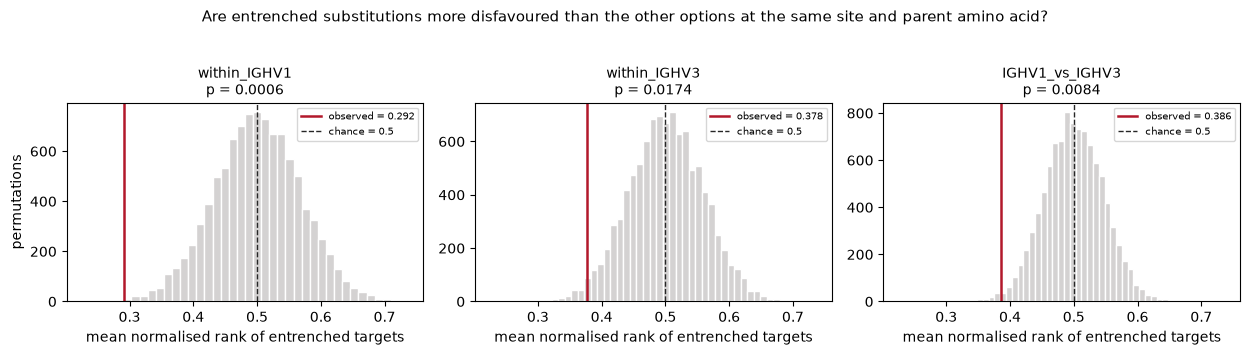

In [7]:
fig, axes = plt.subplots(1, len(COMPARISONS), figsize=(4.2 * len(COMPARISONS), 3.4), sharex=True)

for ax, (name, _, _) in zip(np.atleast_1d(axes), COMPARISONS):
    res = version_b_results[name]
    ax.hist(res["null"], bins=40, color="#D4D2D2", edgecolor="white")
    ax.axvline(res["observed"], color="#B2182B", lw=1.8, label=f"observed = {res['observed']:.3f}")
    ax.axvline(0.5, color="#262626", lw=1.0, ls="--", label="chance = 0.5")
    ax.set_title(f"{name}\np = {res['p_value']:.4f}", fontsize=10)
    ax.set_xlabel("mean normalised rank of entrenched targets")
    ax.legend(fontsize=7)
axes[0].set_ylabel("permutations")

fig.suptitle("Are entrenched substitutions more disfavoured than the other options "
             "at the same site and parent amino acid?", y=1.03, fontsize=11)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/within_site_null_pooled_rank.pdf", bbox_inches="tight")
plt.show()

In [8]:
summary = pd.DataFrame([{
    "comparison": name,
    "entrenched targets": version_b_results[name]["n_entrenched"],
    "A: groups p<=0.05": f"{(version_a_tables[name].p_exact <= 0.05).sum()}/{len(version_a_tables[name])}",
    "A: Fisher p": stats.chi2.sf(
        -2 * np.log(version_a_tables[name].p_exact.clip(lower=1e-12)).sum(),
        2 * len(version_a_tables[name])),
    "B: mean rank": version_b_results[name]["observed"],
    "B: p": version_b_results[name]["p_value"],
    "readout 2 enrichment": readout_2[name]["enrichment"],
} for name, _, _ in COMPARISONS])
print(summary.round(3).to_string(index=False))

    comparison  entrenched targets A: groups p<=0.05  A: Fisher p  B: mean rank  B: p  readout 2 enrichment
  within_IGHV1                  16              0/12        0.172         0.292 0.001                 0.996
  within_IGHV3                  22              0/17        0.439         0.378 0.017                 0.629
IGHV1_vs_IGHV3                  34              0/26        0.522         0.386 0.008                 0.634


## Reading the table

**Version A is null everywhere,** and largely cannot be otherwise: only a handful of groups
have enough targets for any p-value below 0.05 to exist. Report the arrangement floor as a
property of the reviewer's readout (1), not as a finding of ours.

**Version B is positive in all three comparisons.** Entrenched substitutions sit in the
bottom ~30–39% of the options available from their germline parent, against 50% expected by
chance, no single site carries it, and the z-score version agrees. Under the reviewer's
hypothesis this number should have been 0.5.

One limitation to state if we quote the p-value: the two directions of a pair land in two
different groups and are permuted independently, so the test treats them as independent when
they are weakly correlated. The effective sample size is below 16/22/34 and the p-values are
correspondingly optimistic.

**The per-group table in Step 2 is the more direct statement** and should be shown rather
than only the pooled p-value. Averaged over groups, roughly half the available targets fall
below −1 — not all of them. But the range runs from 0.14 to 1.00, and at a handful of groups
every target is below −1. At those the reviewer is literally right that everything is
disfavoured and the within-site test contributes nothing; those are the cases where the
reciprocity argument has to carry the point alone.

**Readout (2) is flat**: randomising the partner produces at least as many configurations as
we observe. It tests partner specificity, a stronger requirement than entrenchment imposes
and one the germline partner is unlikely to meet — most of the pool is residues no V gene
carries at that site, which have never been shown viable there, whereas the germline partner
demonstrably has. Report it plainly with that explanation and build nothing on it.

**None of this settles whether the calls are entrenchment.** Reciprocal disfavour is not
producible by site-level constraint of any strength, for the reason at the top of this
notebook. These tests answer the reviewer's narrower question about within-site specialness;
the claim itself rests on the reciprocity argument.